# 经典卷积模型

使用经典的卷积 + 最大池化 + FC进行试验

模型结构如下：
1. conv2d(kenel_size=2, stride=2, padding=2)
2. ReLU
3. MaxPool(kernel_size=2, stride=2)
4. conv2d(kenel_size=3, stride=1, padding=1)
5. ReLU
6. MaxPool(kenel_size=2, stride=2)
7. FC(16, 4)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from lib.data_loader import *
from lib.train_test import *

In [3]:
# 2. 定义模型结构
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.conv1 = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=2, stride=2, padding=2)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, stride=1, padding=1)  
        self.relu = nn.ReLU()
        self.fc = nn.Linear(16, 4)
    
    def forward(self, x):
        x = self.conv1(x)           
        # print(x.shape)              # down sacle to 25*4*16*16
        x = self.relu(x)        
        x = self.max_pool(x)        
        # print(x.shape)              # 25*4*8*8
        x = self.conv2(x)           
        # print(x.shape)              # 25*16*4*4
        x = self.relu(x)
        x = self.max_pool(x)       
        # print(x.shape)              # to 25*16*2*2
        x = self.conv3(x)
        # print(x.shape)              # 25*16*2*2
        x = self.relu(x)
        x = self.max_pool(x)
        # print(x.shape)              # 25*16*1*1
        x = self.flatten(x)
        # print(x.shape)              # 25*16
        x = self.fc(x)
        # print(x.shape)              # 25*4
        return x

Shape of X [N, C, H, W]:+--------------------------------------------------------------- torch.Size([25, 1, 28, 28])
Shape of y: torch.Size([25]) torch.int64
train_images's shape is :  torch.Size([25, 1, 28, 28])
train_labels's shape is :  torch.Size([25])
Training Samples:


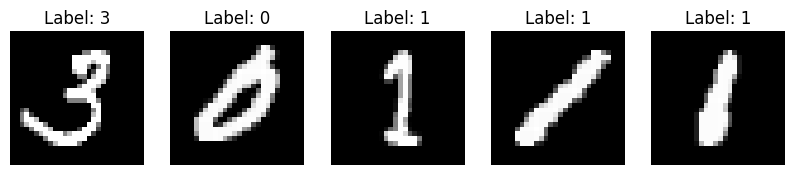

Testing Samples:


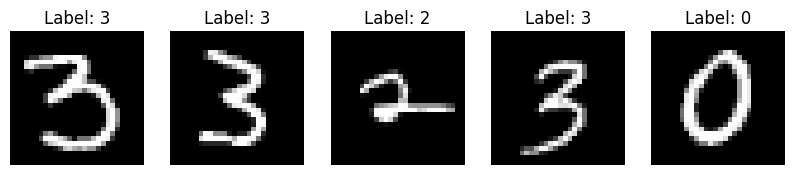

In [4]:
# MNIST 数据集加载
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="../data", train=False, download=True, transform=transform)
train_loader, test_loader = getDataloader(train_dataset, test_dataset, range(4), train_size=3000, test_size=1000, batch_size=25, shuffle=True)


In [5]:

epochs = 10

# 初始化模型、优化器和损失函数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)
print(model)
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.01
optimizer = optim.Adam(model.parameters(), lr = learning_rate)
accuracy_list = []
loss_list = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_multi_channel(train_loader, model, loss_fn, 25, optimizer, device)
    accuracy, loss = test_multi_channel_all(test_loader, model, loss_fn, device)
    accuracy_list.append(accuracy)
    loss_list.append(loss)
print("Done!")

CNNModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv1): Conv2d(4, 4, kernel_size=(2, 2), stride=(2, 2), padding=(2, 2))
  (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(4, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (fc): Linear(in_features=16, out_features=4, bias=True)
)
Epoch 1
-------------------------------
loss: 1.398956  [   25/12000]
loss: 0.464655  [  650/12000]
loss: 0.219849  [ 1275/12000]
loss: 0.225402  [ 1900/12000]
loss: 0.250431  [ 2525/12000]
loss: 0.250640  [ 3150/12000]
loss: 0.113149  [ 3775/12000]
loss: 0.487414  [ 4400/12000]
loss: 0.131035  [ 5025/12000]
loss: 0.078915  [ 5650/12000]
loss: 0.265587  [ 6275/12000]
loss: 0.026927  [ 6900/12000]
loss: 0.033619  [ 7525/12000]
loss: 0.169499  [ 8150/12000]
loss: 0.034620  [ 8775/12000]
loss: 0.139991  [ 9400/12000]
loss: 0.014090  [10025/12000]


In [6]:
print("Accuracy_list: ", accuracy_list)
print("Loss_list: ", loss_list)


Accuracy_list:  [0.9665829145728643, 0.957035175879397, 0.9773869346733668, 0.9798994974874372, 0.9653266331658291, 0.9806532663316583, 0.9806532663316583, 0.9706030150753768, 0.9854271356783919, 0.9758793969849247]
Loss_list:  [0.10802038051770069, 0.12178144800127484, 0.06446655827749055, 0.05900602822903238, 0.1156797504723727, 0.06143591261279653, 0.062381772892149454, 0.09990642014672631, 0.04792479009947783, 0.08783741383822416]
